# NCBI Data Exploration for AMR Prediction

This notebook provides a comprehensive exploration of the NCBI Pathogen Detection dataset used for antimicrobial resistance (AMR) prediction.

## Contents
1. [Setup and Data Loading](#1-setup-and-data-loading)
2. [Metadata Exploration](#2-metadata-exploration)
3. [Genome Sequence Analysis](#3-genome-sequence-analysis)
4. [Organism Distribution](#4-organism-distribution)
5. [AMR Label Analysis](#5-amr-label-analysis)
6. [Feature Exploration](#6-feature-exploration)
7. [Data Quality Assessment](#7-data-quality-assessment)
8. [Summary Statistics](#8-summary-statistics)
9. [Summary: Key Findings](#9-summary-key-findings)
10. [Recommendations](#10-recommendations)
11. [Next Steps](#next-steps)

## 1. Setup and Data Loading

In [1]:
# Import libraries
import sys
import json
import gzip
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

# Configure pandas display
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

# Add project root to path
project_root = Path('.').absolute().parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /Users/jubayer/Projects/DeepAMR


In [2]:
# Define data paths
DATA_DIR = project_root / 'data'
RAW_DIR = DATA_DIR / 'raw' / 'ncbi'
PROCESSED_DIR = DATA_DIR / 'processed' / 'ncbi'

print("Data directories:")
print(f"  Raw data: {RAW_DIR}")
print(f"  Processed data: {PROCESSED_DIR}")
print(f"\nRaw data exists: {RAW_DIR.exists()}")
print(f"Processed data exists: {PROCESSED_DIR.exists()}")

Data directories:
  Raw data: /Users/jubayer/Projects/DeepAMR/data/raw/ncbi
  Processed data: /Users/jubayer/Projects/DeepAMR/data/processed/ncbi

Raw data exists: True
Processed data exists: True


In [3]:
# Load metadata
metadata_files = list((RAW_DIR / 'metadata').glob('*.csv'))
print(f"Found {len(metadata_files)} metadata files:")
for f in sorted(metadata_files):
    print(f"  - {f.name}")

Found 20 metadata files:
  - Acinetobacter_baumannii_metadata.csv
  - Campylobacter_jejuni_metadata.csv
  - Citrobacter_freundii_metadata.csv
  - Clostridioides_difficile_metadata.csv
  - Enterococcus_faecalis_metadata.csv
  - Enterococcus_faecium_metadata.csv
  - Escherichia_coli_metadata.csv
  - Haemophilus_influenzae_metadata.csv
  - Klebsiella_pneumoniae_metadata.csv
  - Listeria_monocytogenes_metadata.csv
  - Mycobacterium_tuberculosis_metadata.csv
  - Neisseria_gonorrhoeae_metadata.csv
  - Neisseria_meningitidis_metadata.csv
  - Pseudomonas_aeruginosa_metadata.csv
  - Salmonella_enterica_metadata.csv
  - Serratia_marcescens_metadata.csv
  - Staphylococcus_aureus_metadata.csv
  - Streptococcus_pneumoniae_metadata.csv
  - Streptococcus_pyogenes_metadata.csv
  - Vibrio_cholerae_metadata.csv


In [4]:
# Load and combine all metadata
all_metadata = []

for csv_file in metadata_files:
    df = pd.read_csv(csv_file)
    all_metadata.append(df)
    print(f"Loaded {len(df):,} records from {csv_file.name}")

# Also load complete metadata if exists
complete_file = RAW_DIR / 'complete_metadata.csv'
if complete_file.exists():
    df = pd.read_csv(complete_file)
    all_metadata.append(df)
    print(f"Loaded {len(df):,} records from complete_metadata.csv")

# Combine and deduplicate
metadata = pd.concat(all_metadata, ignore_index=True)
metadata = metadata.drop_duplicates(subset=['biosample_id'])
metadata['biosample_id'] = metadata['biosample_id'].astype(str)

print(f"\nTotal unique records: {len(metadata):,}")

Loaded 500 records from Citrobacter_freundii_metadata.csv
Loaded 500 records from Vibrio_cholerae_metadata.csv
Loaded 500 records from Mycobacterium_tuberculosis_metadata.csv
Loaded 500 records from Salmonella_enterica_metadata.csv
Loaded 500 records from Campylobacter_jejuni_metadata.csv
Loaded 500 records from Streptococcus_pyogenes_metadata.csv
Loaded 500 records from Clostridioides_difficile_metadata.csv
Loaded 500 records from Escherichia_coli_metadata.csv
Loaded 500 records from Listeria_monocytogenes_metadata.csv
Loaded 500 records from Enterococcus_faecalis_metadata.csv
Loaded 500 records from Staphylococcus_aureus_metadata.csv
Loaded 500 records from Serratia_marcescens_metadata.csv
Loaded 500 records from Haemophilus_influenzae_metadata.csv
Loaded 500 records from Neisseria_meningitidis_metadata.csv
Loaded 500 records from Acinetobacter_baumannii_metadata.csv
Loaded 500 records from Neisseria_gonorrhoeae_metadata.csv
Loaded 500 records from Pseudomonas_aeruginosa_metadata.csv

## 2. Metadata Exploration

In [5]:
# Display metadata structure
print("Metadata columns:")
print(metadata.columns.tolist())
print(f"\nShape: {metadata.shape}")

Metadata columns:
['biosample_id', 'accession', 'organism', 'strain', 'isolation_source', 'host', 'collection_date', 'geo_loc_name', 'amr_genotypes', 'amr_phenotypes', 'disease', 'sra_accession', 'assembly_accession', 'assembly_status', 'ftp_path_refseq', 'ftp_path_genbank', 'organism_query']

Shape: (10000, 17)


In [6]:
# Display sample records
print("Sample metadata records:")
metadata.head(10)

Sample metadata records:


,biosample_id,accession,organism,strain,isolation_source,host,collection_date,geo_loc_name,amr_genotypes,amr_phenotypes,disease,sra_accession,assembly_accession,assembly_status,ftp_path_refseq,ftp_path_genbank,organism_query
0,54870551,SAMN54870551,NaN,2026EP-00014,BRONCHIAL ALVEOLAR LAVAGE,Homo sapiens,2025,USA,NaN,NaN,NaN,NaN,GCA_054687085.1,Contig,NaN,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/054...,Citrobacter freundii
1,54807604,SAMD00899884,NaN,TB25-009W-60-9,NaN,NaN,2025,Viet Nam:Thai Binh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Citrobacter freundii
2,54762434,SAMEA120264337,NaN,NaN,Isolated from sample of chilled mussel at retail,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Citrobacter freundii
3,54760913,SAMEA120264335,NaN,NaN,Isolated from sample of frozen salmon at retail,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Citrobacter freundii
4,54771996,SAMN54771996,NaN,NaN,Water from the Qiantang River was supplemented...,NaN,2025-06-17,China,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Citrobacter freundii
5,54771964,SAMN54771964,NaN,NaN,Water from the Qiantang River was supplemented...,NaN,2025-06-17,China,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Citrobacter freundii
6,54768132,SAMN54768132,NaN,NaN,urine,NaN,2025-10-30,USA,NaN,NaN,NaN,NaN,GCA_054595255.1,Contig,NaN,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/054...,Citrobacter freundii
7,48146735,SAMN48146735,NaN,NaN,rectal swab,Homo sapiens,2024-03-10,Qatar:Doha,NaN,NaN,NaN,NaN,GCA_054402475.1,Contig,NaN,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/054...,Citrobacter freundii
8,54727717,SAMN54727717,NaN,NaN,Water from the Qiantang River was supplemented...,NaN,2025-06-17,China,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Citrobacter freundii
9,54727685,SAMN54727685,NaN,NaN,Water from the Qiantang River was supplemented...,NaN,2025-06-17,China,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Citrobacter freundii


In [7]:
# Data types and missing values
print("Data types and missing values:")
info_df = pd.DataFrame({
    'dtype': metadata.dtypes,
    'non_null': metadata.count(),
    'null_count': metadata.isnull().sum(),
    'null_pct': (metadata.isnull().sum() / len(metadata) * 100).round(2)
})
info_df

Data types and missing values:


,dtype,non_null,null_count,null_pct
biosample_id,object,10000,0,0.00
accession,object,10000,0,0.00
organism,object,18,9982,99.82
strain,object,6010,3990,39.90
isolation_source,object,7839,2161,21.61
host,object,6190,3810,38.10
collection_date,object,8061,1939,19.39
geo_loc_name,object,8079,1921,19.21
amr_genotypes,float64,0,10000,100.00
amr_phenotypes,float64,0,10000,100.00


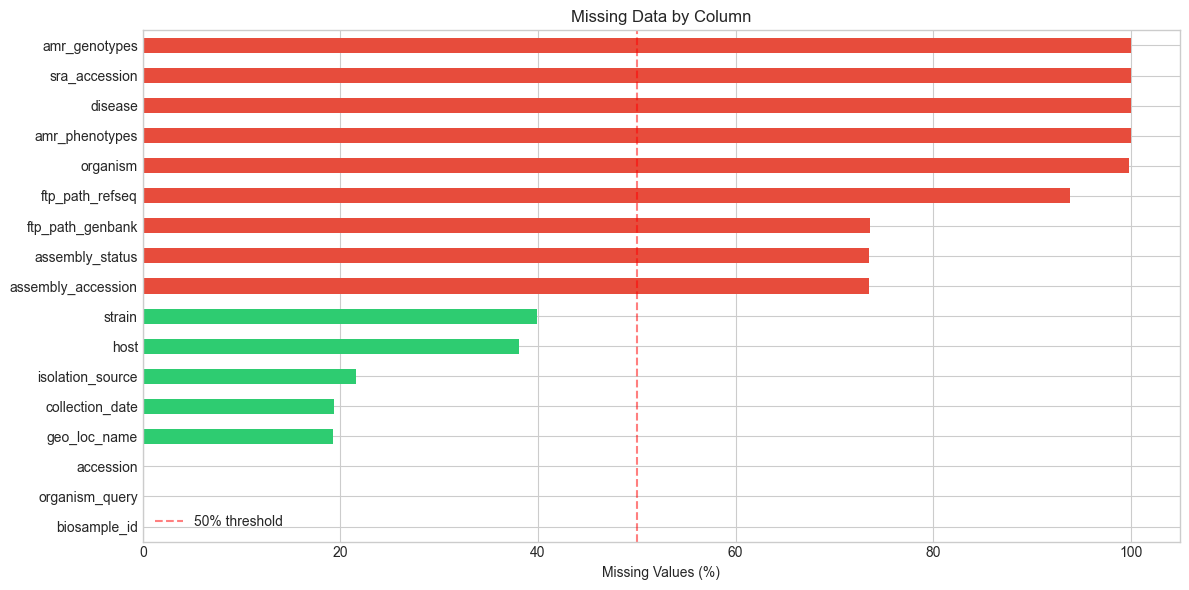

In [8]:
# Visualize missing data
fig, ax = plt.subplots(figsize=(12, 6))

missing_pct = (metadata.isnull().sum() / len(metadata) * 100).sort_values(ascending=True)
colors = ['#2ecc71' if x < 50 else '#e74c3c' for x in missing_pct]

missing_pct.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Data by Column')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()

plt.tight_layout()
plt.show()

## 3. Genome Sequence Analysis

In [9]:
# Count available genome files
genomes_dir = RAW_DIR / 'genomes'
genome_files = list(genomes_dir.glob('*.fna.gz'))
print(f"Total genome files: {len(genome_files):,}")

# Get biosample IDs from genome files
genome_biosample_ids = set(f.stem.replace('.fna', '') for f in genome_files)
print(f"Unique biosample IDs with genomes: {len(genome_biosample_ids):,}")

Total genome files: 864
Unique biosample IDs with genomes: 864


In [10]:
# Calculate genome statistics (sample a subset for speed)
def get_genome_stats(genome_file, max_files=100):
    """Calculate basic genome statistics."""
    try:
        with gzip.open(genome_file, 'rt') as f:
            sequence = ''
            for line in f:
                if not line.startswith('>'):
                    sequence += line.strip()
        
        seq_upper = sequence.upper()
        length = len(sequence)
        gc_count = seq_upper.count('G') + seq_upper.count('C')
        gc_content = gc_count / length if length > 0 else 0
        n_count = seq_upper.count('N')
        
        return {
            'biosample_id': genome_file.stem.replace('.fna', ''),
            'length': length,
            'gc_content': gc_content,
            'n_count': n_count,
            'n_pct': n_count / length * 100 if length > 0 else 0
        }
    except Exception as e:
        return None

# Sample genomes for analysis
sample_size = min(100, len(genome_files))
sampled_files = np.random.choice(genome_files, size=sample_size, replace=False)

print(f"Analyzing {sample_size} genome files...")
genome_stats = []
for i, gf in enumerate(sampled_files):
    stats = get_genome_stats(gf)
    if stats:
        genome_stats.append(stats)
    if (i + 1) % 20 == 0:
        print(f"  Processed {i + 1}/{sample_size}")

genome_df = pd.DataFrame(genome_stats)
print(f"\nSuccessfully analyzed {len(genome_df)} genomes")

Analyzing 100 genome files...
  Processed 20/100
  Processed 40/100
  Processed 60/100
  Processed 80/100
  Processed 100/100

Successfully analyzed 100 genomes


In [11]:
# Display genome statistics
print("Genome Statistics Summary:")
genome_df[['length', 'gc_content', 'n_count', 'n_pct']].describe()

Genome Statistics Summary:


,length,gc_content,n_count,n_pct
count,1.000000e+02,100.000000,100.000000,100.000000
mean,4.747975e+06,0.478651,190.610000,0.004540
std,1.158054e+06,0.098485,903.187955,0.027760
min,2.820285e+06,0.326131,0.000000,0.000000
25%,3.985764e+06,0.388925,0.000000,0.000000
50%,4.758037e+06,0.504268,0.000000,0.000000
75%,5.470668e+06,0.565221,0.000000,0.000000
max,7.425744e+06,0.664936,7706.000000,0.268464


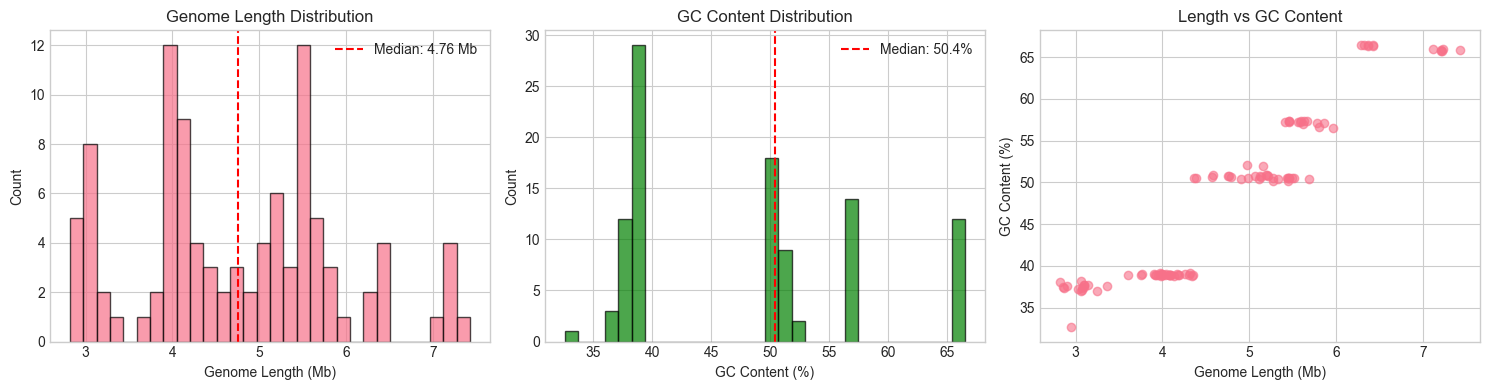

In [12]:
# Visualize genome length distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Genome length
axes[0].hist(genome_df['length'] / 1e6, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Genome Length (Mb)')
axes[0].set_ylabel('Count')
axes[0].set_title('Genome Length Distribution')
axes[0].axvline(genome_df['length'].median() / 1e6, color='red', linestyle='--', 
                label=f"Median: {genome_df['length'].median()/1e6:.2f} Mb")
axes[0].legend()

# GC content
axes[1].hist(genome_df['gc_content'] * 100, bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('GC Content (%)')
axes[1].set_ylabel('Count')
axes[1].set_title('GC Content Distribution')
axes[1].axvline(genome_df['gc_content'].median() * 100, color='red', linestyle='--',
                label=f"Median: {genome_df['gc_content'].median()*100:.1f}%")
axes[1].legend()

# Length vs GC content
axes[2].scatter(genome_df['length'] / 1e6, genome_df['gc_content'] * 100, alpha=0.6)
axes[2].set_xlabel('Genome Length (Mb)')
axes[2].set_ylabel('GC Content (%)')
axes[2].set_title('Length vs GC Content')

plt.tight_layout()
plt.show()

## 4. Organism Distribution

In [13]:
# Organism distribution from metadata
organism_counts = metadata['organism_query'].value_counts()
print(f"Number of unique organisms: {len(organism_counts)}")
print(f"\nOrganism distribution:")
organism_counts

Number of unique organisms: 20

Organism distribution:


organism_query
Citrobacter freundii          500
Vibrio cholerae               500
Enterococcus faecium          500
Streptococcus pneumoniae      500
Pseudomonas aeruginosa        500
Neisseria gonorrhoeae         500
Acinetobacter baumannii       500
Neisseria meningitidis        500
Haemophilus influenzae        500
Serratia marcescens           500
Staphylococcus aureus         500
Enterococcus faecalis         500
Listeria monocytogenes        500
Escherichia coli              500
Clostridioides difficile      500
Streptococcus pyogenes        500
Campylobacter jejuni          500
Salmonella enterica           500
Mycobacterium tuberculosis    500
Klebsiella pneumoniae         500
Name: count, dtype: int64

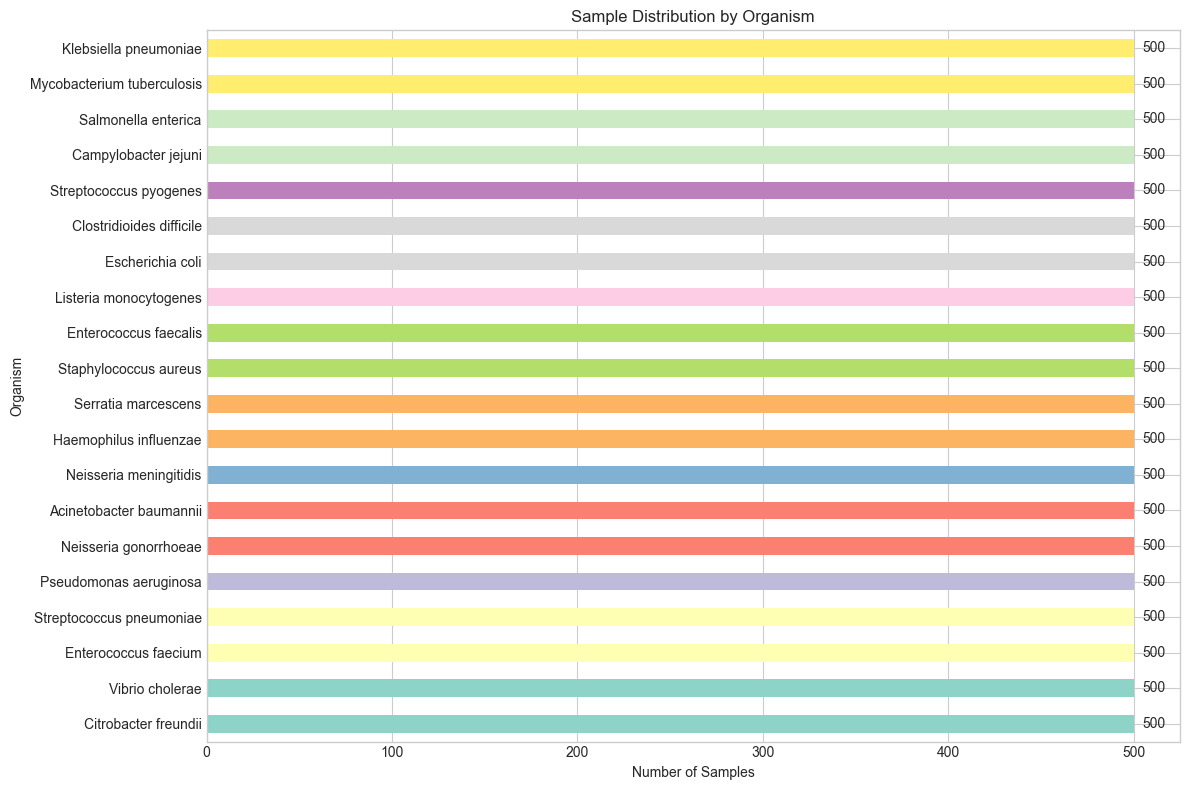

In [14]:
# Visualize organism distribution
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.Set3(np.linspace(0, 1, len(organism_counts)))
organism_counts.plot(kind='barh', ax=ax, color=colors)

ax.set_xlabel('Number of Samples')
ax.set_ylabel('Organism')
ax.set_title('Sample Distribution by Organism')

# Add count labels
for i, v in enumerate(organism_counts.values):
    ax.text(v + 5, i, str(v), va='center')

plt.tight_layout()
plt.show()

In [15]:
# Check which organisms have genome sequences available
metadata_with_genomes = metadata[metadata['biosample_id'].isin(genome_biosample_ids)]
organism_with_genomes = metadata_with_genomes['organism_query'].value_counts()

print(f"Organisms with genome sequences available:")
print(f"Total samples with genomes: {len(metadata_with_genomes):,}")
print(f"\nDistribution:")
organism_with_genomes

Organisms with genome sequences available:
Total samples with genomes: 864

Distribution:


organism_query
Acinetobacter baumannii    279
Escherichia coli           202
Pseudomonas aeruginosa     124
Enterococcus faecalis      106
Klebsiella pneumoniae       79
Enterococcus faecium        55
Salmonella enterica         12
Staphylococcus aureus        7
Name: count, dtype: int64

In [16]:
# Compare metadata vs available genomes
comparison_df = pd.DataFrame({
    'Total Metadata': organism_counts,
    'With Genomes': organism_with_genomes
}).fillna(0).astype(int)
comparison_df['Coverage (%)'] = (comparison_df['With Genomes'] / comparison_df['Total Metadata'] * 100).round(1)

print("Genome availability by organism:")
comparison_df.sort_values('With Genomes', ascending=False)

Genome availability by organism:


,Total Metadata,With Genomes,Coverage (%)
organism_query,,,
Acinetobacter baumannii,500,279,55.8
Escherichia coli,500,202,40.4
Pseudomonas aeruginosa,500,124,24.8
Enterococcus faecalis,500,106,21.2
Klebsiella pneumoniae,500,79,15.8
Enterococcus faecium,500,55,11.0
Salmonella enterica,500,12,2.4
Staphylococcus aureus,500,7,1.4
Neisseria meningitidis,500,0,0.0


## 5. AMR Label Analysis

In [17]:
# Load AMR labels
amr_labels_file = RAW_DIR / 'amr_annotations' / 'amr_labels.csv'

if amr_labels_file.exists():
    amr_labels = pd.read_csv(amr_labels_file)
    amr_labels['biosample_id'] = amr_labels['biosample_id'].astype(str)
    print(f"Loaded AMR labels for {len(amr_labels):,} samples")
    print(f"\nColumns: {amr_labels.columns.tolist()}")
else:
    print("AMR labels file not found. Run AMRFinderPlus pipeline first.")
    amr_labels = None

Loaded AMR labels for 862 samples

Columns: ['biosample_id', 'aminoglycoside', 'beta-lactam', 'colistin', 'fosfomycin', 'fusidic_acid', 'glycopeptide', 'macrolide', 'nitroimidazole', 'oxazolidinone', 'phenicol', 'quinolone', 'rifampicin', 'sulfonamide', 'tetracycline', 'trimethoprim']


In [18]:
if amr_labels is not None:
    # Get drug class columns
    drug_columns = [c for c in amr_labels.columns if c != 'biosample_id']
    print(f"Drug classes ({len(drug_columns)}): {drug_columns}")
    
    # Display sample AMR labels
    print("\nSample AMR labels:")
    display(amr_labels.head(10))

Drug classes (15): ['aminoglycoside', 'beta-lactam', 'colistin', 'fosfomycin', 'fusidic_acid', 'glycopeptide', 'macrolide', 'nitroimidazole', 'oxazolidinone', 'phenicol', 'quinolone', 'rifampicin', 'sulfonamide', 'tetracycline', 'trimethoprim']

Sample AMR labels:


,biosample_id,aminoglycoside,beta-lactam,colistin,fosfomycin,fusidic_acid,glycopeptide,macrolide,nitroimidazole,oxazolidinone,phenicol,quinolone,rifampicin,sulfonamide,tetracycline,trimethoprim
0,40889915,1,1,0,1,0,0,0,0,0,1,0,0,0,1,0
1,54529271,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0
2,54802006,1,0,0,1,0,0,0,0,0,0,0,0,1,1,0
3,53668798,1,0,0,0,0,0,1,0,1,1,0,0,0,1,1
4,54496757,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
5,54764853,1,1,0,0,0,0,1,0,0,0,0,0,1,1,0
6,54456457,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0
7,48146744,1,1,0,1,0,0,1,0,0,1,1,1,1,0,1
8,54767677,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,54769195,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0


In [19]:
if amr_labels is not None:
    # Calculate resistance prevalence for each drug class
    drug_prevalence = amr_labels[drug_columns].sum().sort_values(ascending=False)
    drug_prevalence_pct = (drug_prevalence / len(amr_labels) * 100).round(1)
    
    prevalence_df = pd.DataFrame({
        'Resistant Samples': drug_prevalence,
        'Prevalence (%)': drug_prevalence_pct
    })
    
    print("AMR Prevalence by Drug Class:")
    display(prevalence_df)

AMR Prevalence by Drug Class:


,Resistant Samples,Prevalence (%)
aminoglycoside,643,74.6
beta-lactam,597,69.3
tetracycline,505,58.6
macrolide,399,46.3
sulfonamide,391,45.4
phenicol,298,34.6
fosfomycin,218,25.3
trimethoprim,216,25.1
quinolone,133,15.4
glycopeptide,52,6.0


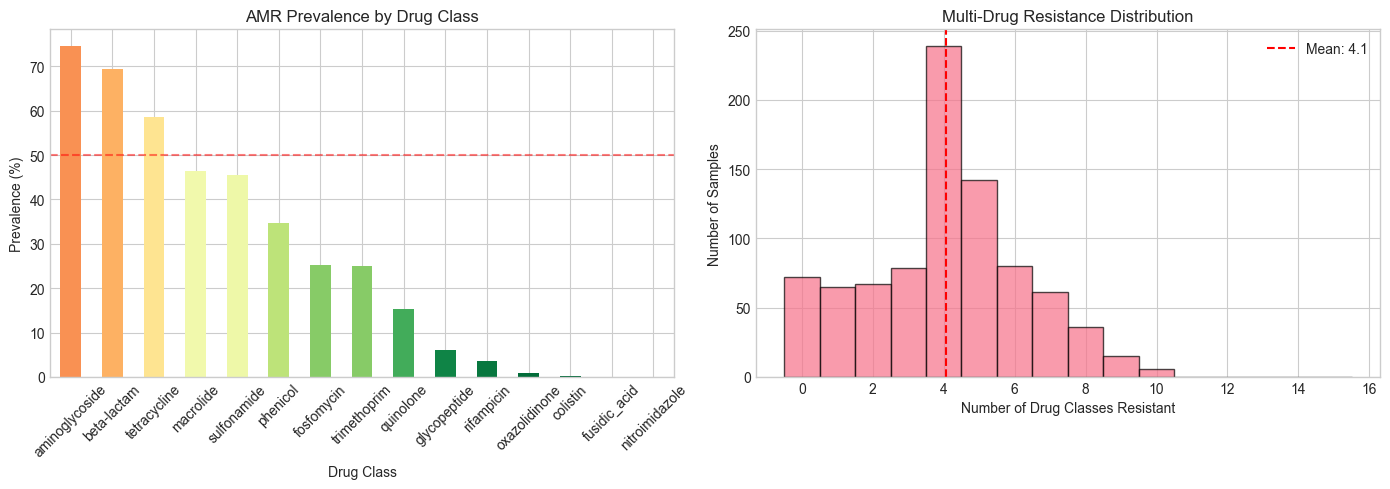


Multi-drug resistance statistics:
  Mean drug classes resistant: 4.05
  Median: 4
  Max: 10
  Samples with no resistance: 72


In [20]:
if amr_labels is not None:
    # Visualize drug resistance prevalence
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot of prevalence
    colors = plt.cm.RdYlGn_r(drug_prevalence_pct.values / 100)
    drug_prevalence_pct.plot(kind='bar', ax=axes[0], color=colors)
    axes[0].set_ylabel('Prevalence (%)')
    axes[0].set_xlabel('Drug Class')
    axes[0].set_title('AMR Prevalence by Drug Class')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].axhline(y=50, color='red', linestyle='--', alpha=0.5)
    
    # Distribution of resistance count per sample
    resistance_per_sample = amr_labels[drug_columns].sum(axis=1)
    axes[1].hist(resistance_per_sample, bins=range(0, len(drug_columns)+2), 
                 edgecolor='black', alpha=0.7, align='left')
    axes[1].set_xlabel('Number of Drug Classes Resistant')
    axes[1].set_ylabel('Number of Samples')
    axes[1].set_title('Multi-Drug Resistance Distribution')
    axes[1].axvline(resistance_per_sample.mean(), color='red', linestyle='--',
                    label=f'Mean: {resistance_per_sample.mean():.1f}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nMulti-drug resistance statistics:")
    print(f"  Mean drug classes resistant: {resistance_per_sample.mean():.2f}")
    print(f"  Median: {resistance_per_sample.median():.0f}")
    print(f"  Max: {resistance_per_sample.max():.0f}")
    print(f"  Samples with no resistance: {(resistance_per_sample == 0).sum()}")

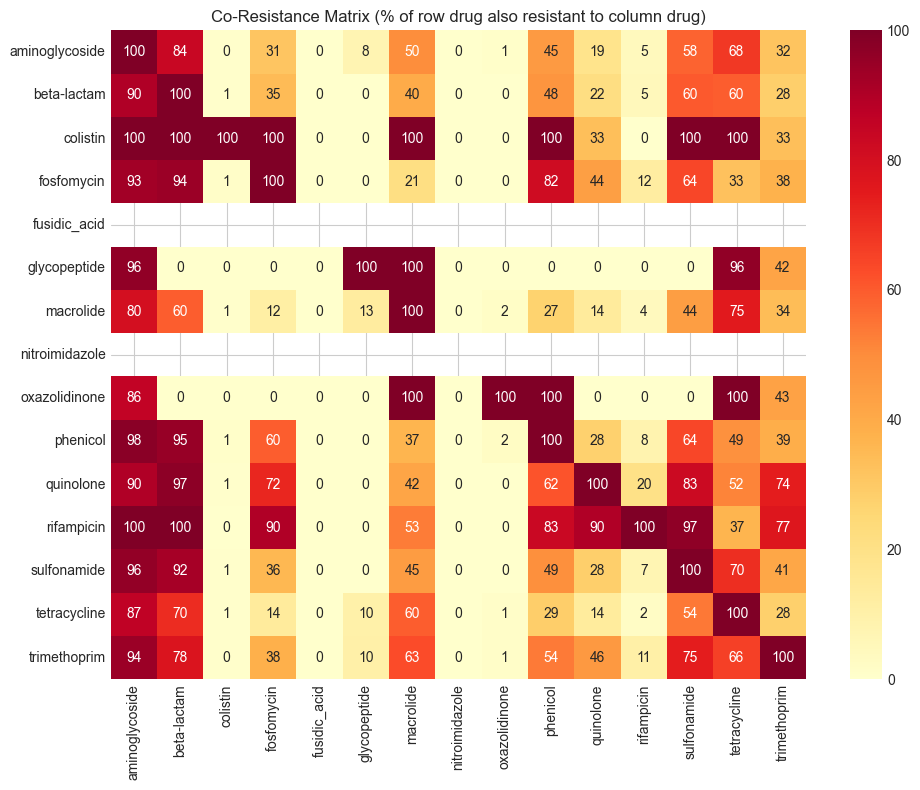

In [21]:
if amr_labels is not None:
    # Co-resistance heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Calculate co-occurrence matrix
    co_occurrence = amr_labels[drug_columns].T.dot(amr_labels[drug_columns])
    
    # Normalize by diagonal (self-occurrence)
    diag = np.diag(co_occurrence).reshape(-1, 1)
    co_resistance_pct = co_occurrence / diag * 100
    
    sns.heatmap(co_resistance_pct, annot=True, fmt='.0f', cmap='YlOrRd',
                xticklabels=drug_columns, yticklabels=drug_columns, ax=ax)
    ax.set_title('Co-Resistance Matrix (% of row drug also resistant to column drug)')
    
    plt.tight_layout()
    plt.show()

## 6. Feature Exploration

In [22]:
# Load processed features
try:
    X_train = np.load(PROCESSED_DIR / 'ncbi_organism_X_train.npy')
    X_val = np.load(PROCESSED_DIR / 'ncbi_organism_X_val.npy')
    X_test = np.load(PROCESSED_DIR / 'ncbi_organism_X_test.npy')
    y_train = np.load(PROCESSED_DIR / 'ncbi_organism_y_train.npy')
    y_val = np.load(PROCESSED_DIR / 'ncbi_organism_y_val.npy')
    y_test = np.load(PROCESSED_DIR / 'ncbi_organism_y_test.npy')
    
    with open(PROCESSED_DIR / 'ncbi_organism_metadata.json') as f:
        organism_metadata = json.load(f)
    
    print("Organism Classification Dataset Loaded:")
    print(f"  X_train shape: {X_train.shape}")
    print(f"  X_val shape: {X_val.shape}")
    print(f"  X_test shape: {X_test.shape}")
    print(f"  Classes: {organism_metadata['class_names']}")
    
    features_loaded = True
except FileNotFoundError as e:
    print(f"Processed features not found: {e}")
    print("Run the preprocessing pipeline first.")
    features_loaded = False

Organism Classification Dataset Loaded:
  X_train shape: (602, 500)
  X_val shape: (87, 500)
  X_test shape: (173, 500)
  Classes: ['Acinetobacter baumannii', 'Enterococcus faecalis', 'Enterococcus faecium', 'Escherichia coli', 'Klebsiella pneumoniae', 'Pseudomonas aeruginosa', 'Salmonella enterica', 'Staphylococcus aureus']


In [23]:
if features_loaded:
    # Feature statistics
    X_all = np.vstack([X_train, X_val, X_test])
    
    print("K-mer Feature Statistics:")
    print(f"  Number of features: {X_all.shape[1]}")
    print(f"  K-mer size: {organism_metadata.get('k', 6)}")
    print(f"  Feature value range: [{X_all.min():.6f}, {X_all.max():.6f}]")
    print(f"  Mean feature value: {X_all.mean():.6f}")
    print(f"  Std feature value: {X_all.std():.6f}")

K-mer Feature Statistics:
  Number of features: 500
  K-mer size: 6
  Feature value range: [0.000000, 0.003390]
  Mean feature value: 0.000503
  Std feature value: 0.000362


In [24]:
if features_loaded:
    # Top k-mer features
    feature_names = organism_metadata['feature_names']
    feature_means = X_all.mean(axis=0)
    
    # Sort by mean frequency
    sorted_indices = np.argsort(feature_means)[::-1]
    
    print("Top 20 K-mers by Mean Frequency:")
    for i in range(20):
        idx = sorted_indices[i]
        print(f"  {i+1}. {feature_names[idx]}: {feature_means[idx]:.6f}")

Top 20 K-mers by Mean Frequency:
  1. AAAAAA: 0.001250
  2. TTTTTT: 0.001199
  3. ATTTTT: 0.001124
  4. AAAAAT: 0.001119
  5. TAAAAA: 0.000993
  6. TTTTTA: 0.000983
  7. TTTTTC: 0.000924
  8. TTTAAA: 0.000913
  9. GAAAAA: 0.000907
  10. AAAATA: 0.000868
  11. TTAAAA: 0.000866
  12. TATTTT: 0.000862
  13. TTTTAA: 0.000856
  14. AATAAA: 0.000854
  15. CTTTTT: 0.000843
  16. AATTTT: 0.000839
  17. AAAAAG: 0.000838
  18. TTTATT: 0.000832
  19. AAAATT: 0.000832
  20. AAATAA: 0.000811


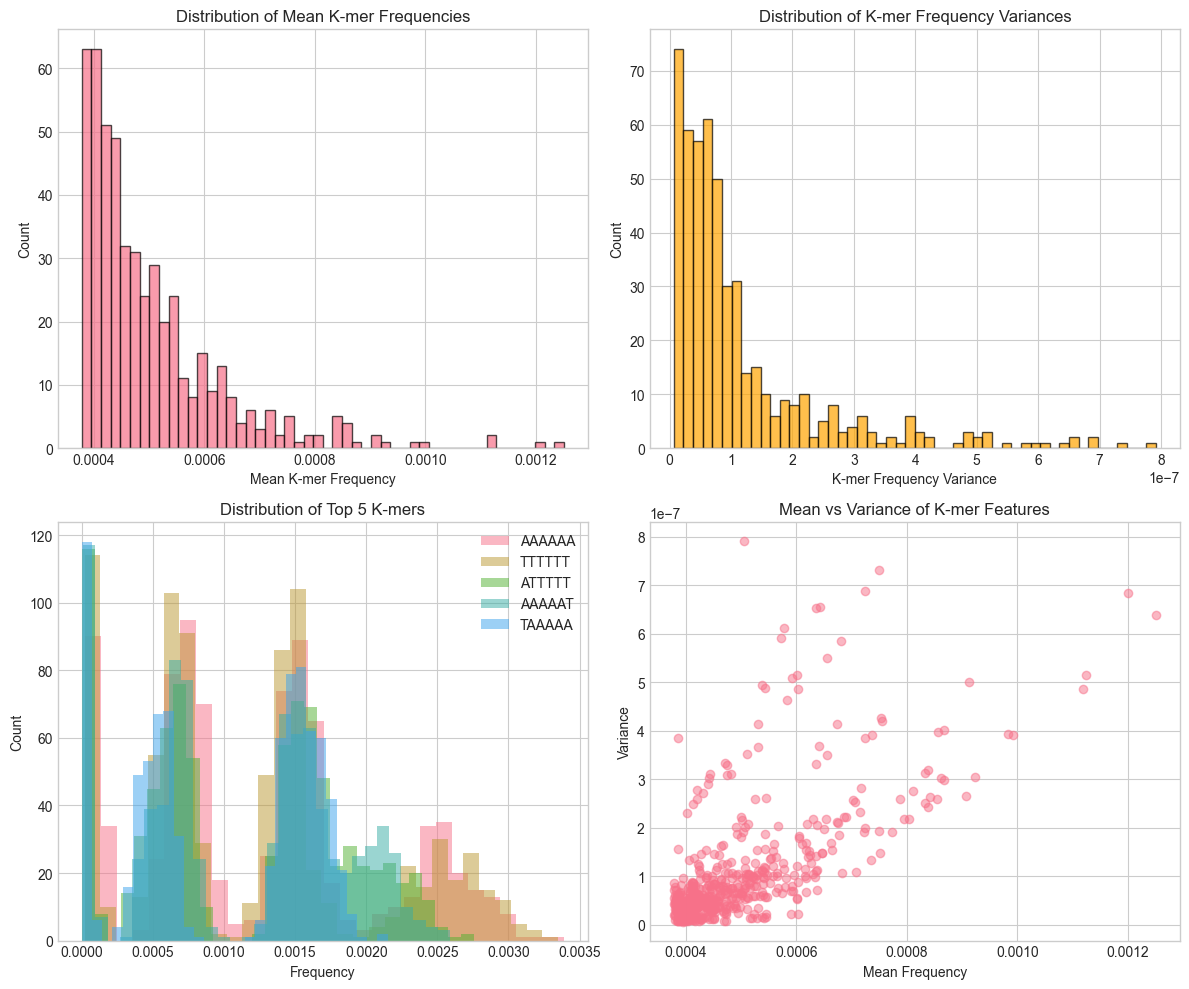

In [25]:
if features_loaded:
    # Visualize feature distributions
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Feature mean distribution
    axes[0, 0].hist(feature_means, bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Mean K-mer Frequency')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title('Distribution of Mean K-mer Frequencies')
    
    # Feature variance
    feature_vars = X_all.var(axis=0)
    axes[0, 1].hist(feature_vars, bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[0, 1].set_xlabel('K-mer Frequency Variance')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title('Distribution of K-mer Frequency Variances')
    
    # Sample feature distributions (top 5 k-mers)
    for i in range(5):
        idx = sorted_indices[i]
        axes[1, 0].hist(X_all[:, idx], bins=30, alpha=0.5, label=feature_names[idx])
    axes[1, 0].set_xlabel('Frequency')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('Distribution of Top 5 K-mers')
    axes[1, 0].legend()
    
    # Mean vs Variance
    axes[1, 1].scatter(feature_means, feature_vars, alpha=0.5)
    axes[1, 1].set_xlabel('Mean Frequency')
    axes[1, 1].set_ylabel('Variance')
    axes[1, 1].set_title('Mean vs Variance of K-mer Features')
    
    plt.tight_layout()
    plt.show()

PCA explained variance: 90.1%
  PC1: 84.9%
  PC2: 5.1%


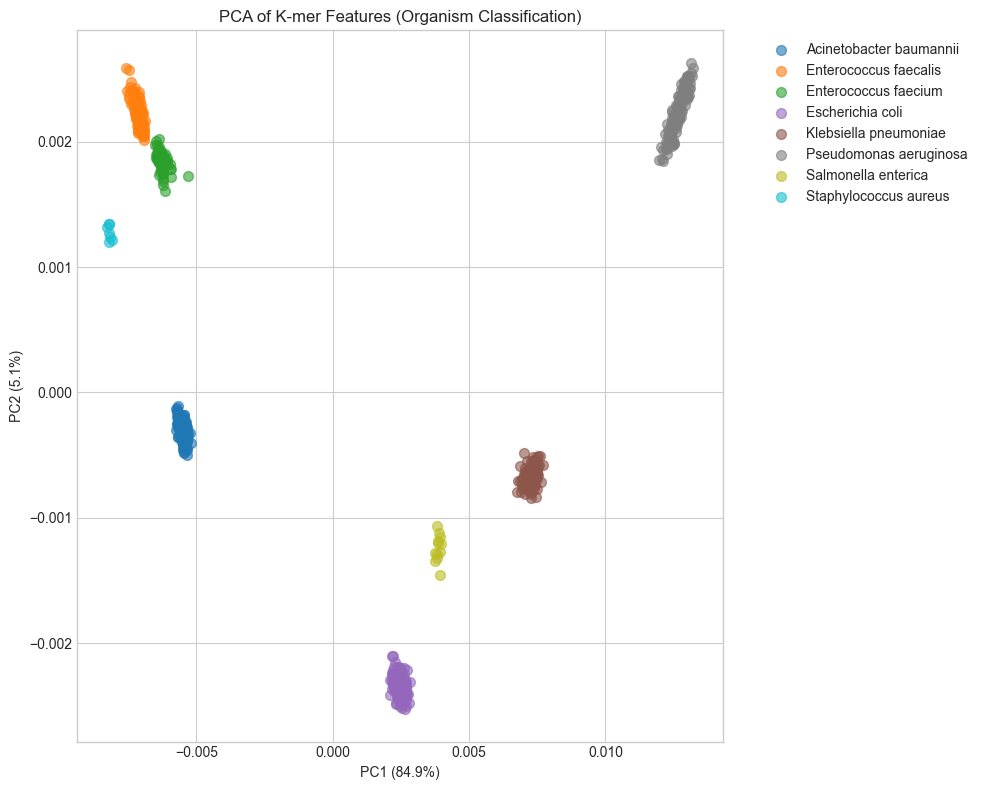

In [26]:
if features_loaded:
    # PCA visualization
    from sklearn.decomposition import PCA
    
    # Combine all data
    y_all = np.concatenate([y_train, y_val, y_test])
    
    # Fit PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_all)
    
    print(f"PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")
    print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
    print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    class_names = organism_metadata['class_names']
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))
    
    for i, class_name in enumerate(class_names):
        mask = y_all == i
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors[i]], 
                   label=class_name, alpha=0.6, s=50)
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('PCA of K-mer Features (Organism Classification)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

## 7. Data Quality Assessment

Top 20 Geographic Locations:
Unique locations: 371
Missing: 1921 (19.2%)


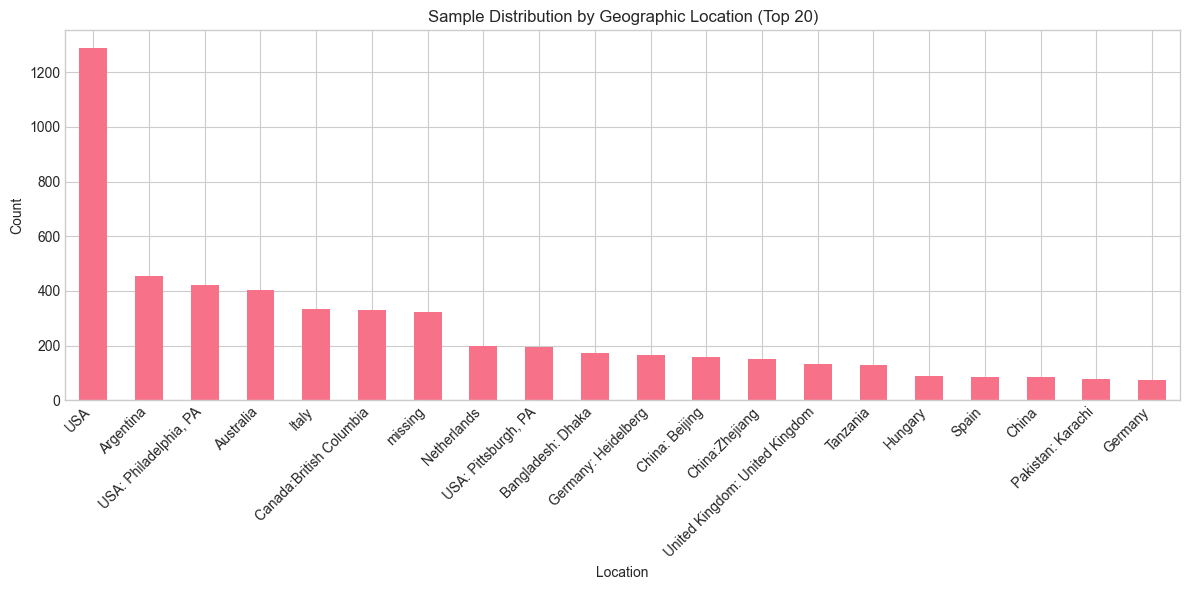

In [27]:
# Geographic distribution
if 'geo_loc_name' in metadata.columns:
    geo_counts = metadata['geo_loc_name'].value_counts().head(20)
    
    print(f"Top 20 Geographic Locations:")
    print(f"Unique locations: {metadata['geo_loc_name'].nunique()}")
    print(f"Missing: {metadata['geo_loc_name'].isna().sum()} ({metadata['geo_loc_name'].isna().mean()*100:.1f}%)")
    
    fig, ax = plt.subplots(figsize=(12, 6))
    geo_counts.plot(kind='bar', ax=ax)
    ax.set_xlabel('Location')
    ax.set_ylabel('Count')
    ax.set_title('Sample Distribution by Geographic Location (Top 20)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Top 20 Isolation Sources:
Unique sources: 617
Missing: 2161 (21.6%)


/var/folders/dv/4kc_pzh50sq17ftyxmspzhbh0000gn/T/ipykernel_12506/783084063.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


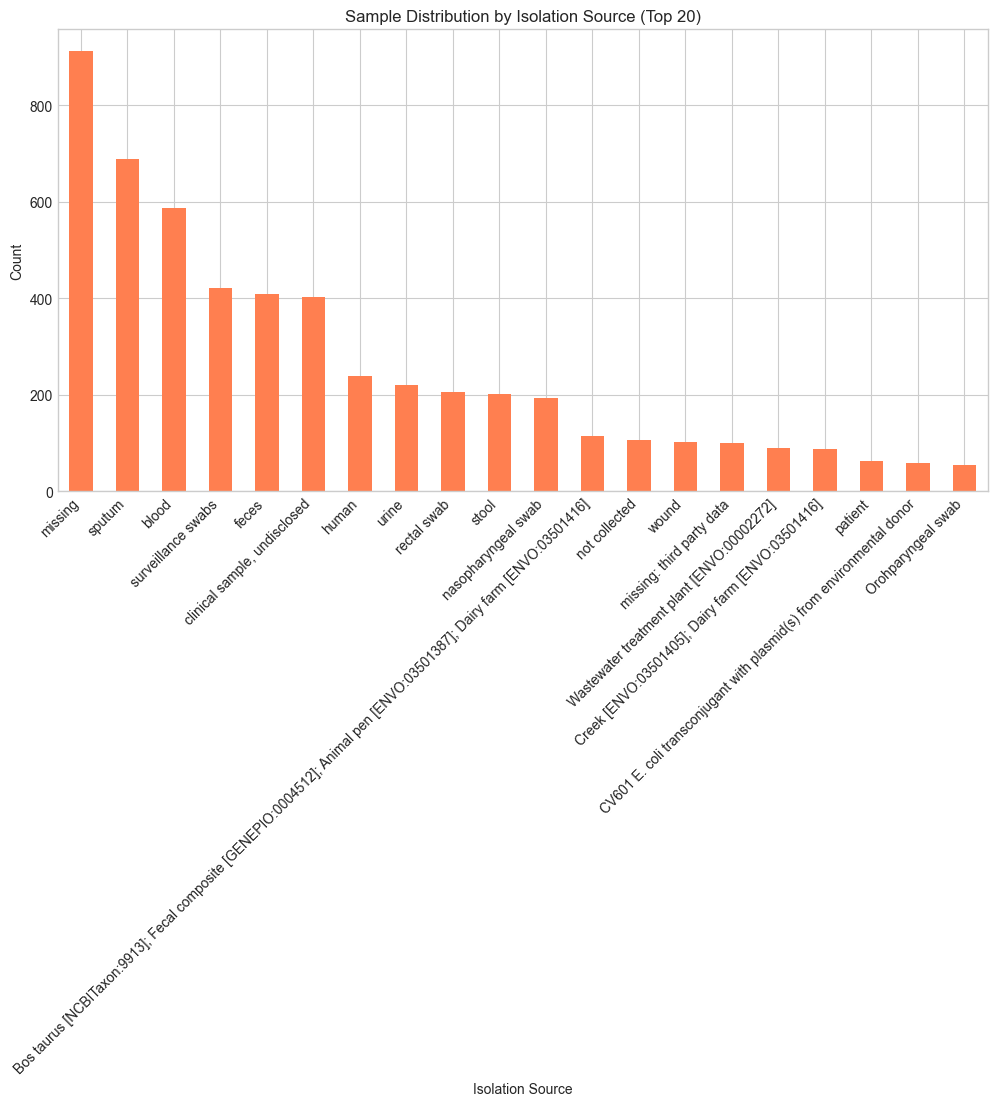

In [28]:
# Isolation source distribution
if 'isolation_source' in metadata.columns:
    iso_counts = metadata['isolation_source'].value_counts().head(20)
    
    print(f"Top 20 Isolation Sources:")
    print(f"Unique sources: {metadata['isolation_source'].nunique()}")
    print(f"Missing: {metadata['isolation_source'].isna().sum()} ({metadata['isolation_source'].isna().mean()*100:.1f}%)")
    
    fig, ax = plt.subplots(figsize=(12, 6))
    iso_counts.plot(kind='bar', ax=ax, color='coral')
    ax.set_xlabel('Isolation Source')
    ax.set_ylabel('Count')
    ax.set_title('Sample Distribution by Isolation Source (Top 20)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [29]:
# Host distribution
if 'host' in metadata.columns:
    host_counts = metadata['host'].value_counts().head(10)
    
    print(f"Top 10 Hosts:")
    print(f"Unique hosts: {metadata['host'].nunique()}")
    display(host_counts)

Top 10 Hosts:
Unique hosts: 90


host
Homo sapiens                        5138
Cattle                               257
Not Applicable [GENEPIO:0001619]     193
Bos taurus [NCBITaxon:9913]          136
Sheep                                 80
not collected                         64
missing                               40
Gallus gallus                         24
H. sapiens                            21
Gyps fulvus                           19
Name: count, dtype: int64

Collection Year Distribution:
Samples with parseable dates: 7,357
Year range: 1973 - 2026


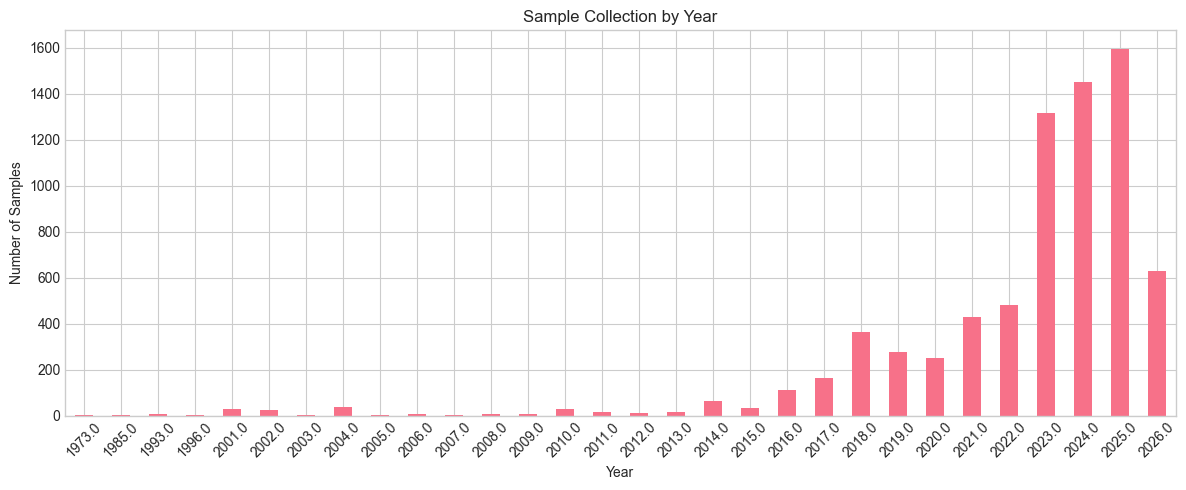

In [30]:
# Collection date analysis
if 'collection_date' in metadata.columns:
    # Parse dates (handle various formats)
    dates = metadata['collection_date'].dropna()
    
    # Extract year where possible
    def extract_year(date_str):
        try:
            if pd.isna(date_str) or date_str == '':
                return None
            date_str = str(date_str)
            # Try to extract 4-digit year
            import re
            match = re.search(r'(19|20)\d{2}', date_str)
            if match:
                return int(match.group())
            return None
        except:
            return None
    
    years = metadata['collection_date'].apply(extract_year).dropna()
    
    if len(years) > 0:
        year_counts = years.value_counts().sort_index()
        
        print(f"Collection Year Distribution:")
        print(f"Samples with parseable dates: {len(years):,}")
        print(f"Year range: {int(years.min())} - {int(years.max())}")
        
        fig, ax = plt.subplots(figsize=(12, 5))
        year_counts.plot(kind='bar', ax=ax)
        ax.set_xlabel('Year')
        ax.set_ylabel('Number of Samples')
        ax.set_title('Sample Collection by Year')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

## 8. Summary Statistics

In [31]:
# Comprehensive summary
print("="*60)
print("NCBI DATA SUMMARY")
print("="*60)

print("\n--- Metadata ---")
print(f"Total metadata records: {len(metadata):,}")
print(f"Unique organisms: {metadata['organism_query'].nunique()}")

print("\n--- Genome Sequences ---")
print(f"Total genome files: {len(genome_files):,}")
print(f"Samples with genomes: {len(genome_biosample_ids):,}")
if len(genome_df) > 0:
    print(f"Mean genome length: {genome_df['length'].mean()/1e6:.2f} Mb")
    print(f"Mean GC content: {genome_df['gc_content'].mean()*100:.1f}%")

if amr_labels is not None:
    print("\n--- AMR Labels ---")
    print(f"Samples with AMR labels: {len(amr_labels):,}")
    print(f"Drug classes: {len(drug_columns)}")
    print(f"Mean resistance per sample: {resistance_per_sample.mean():.1f} drug classes")

if features_loaded:
    print("\n--- Processed Features ---")
    print(f"Training samples: {len(X_train):,}")
    print(f"Validation samples: {len(X_val):,}")
    print(f"Test samples: {len(X_test):,}")
    print(f"Number of features: {X_train.shape[1]}")
    print(f"Number of classes: {len(organism_metadata['class_names'])}")

print("\n" + "="*60)

NCBI DATA SUMMARY

--- Metadata ---
Total metadata records: 10,000
Unique organisms: 20

--- Genome Sequences ---
Total genome files: 864
Samples with genomes: 864
Mean genome length: 4.75 Mb
Mean GC content: 47.9%

--- AMR Labels ---
Samples with AMR labels: 862
Drug classes: 15
Mean resistance per sample: 4.1 drug classes

--- Processed Features ---
Training samples: 602
Validation samples: 87
Test samples: 173
Number of features: 500
Number of classes: 8



Class Distribution in Training Set:
  Acinetobacter baumannii: 193 (32.1%)
  Enterococcus faecalis: 74 (12.3%)
  Enterococcus faecium: 38 (6.3%)
  Escherichia coli: 141 (23.4%)
  Klebsiella pneumoniae: 55 (9.1%)
  Pseudomonas aeruginosa: 87 (14.5%)
  Salmonella enterica: 9 (1.5%)
  Staphylococcus aureus: 5 (0.8%)


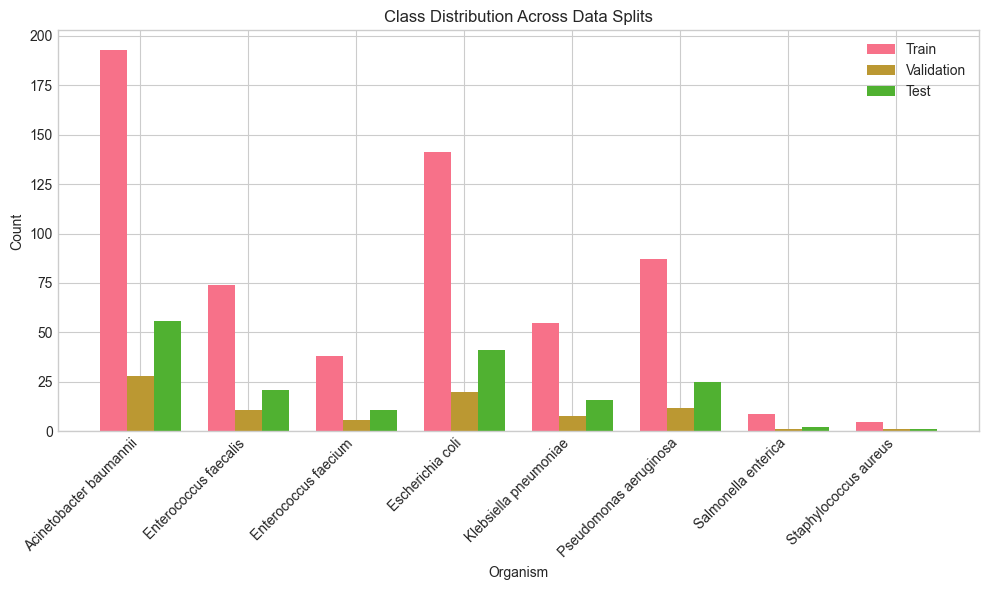

In [32]:
# Class distribution in training set
if features_loaded:
    print("Class Distribution in Training Set:")
    train_counts = pd.Series(y_train).value_counts().sort_index()
    
    for i, count in enumerate(train_counts):
        pct = count / len(y_train) * 100
        print(f"  {organism_metadata['class_names'][i]}: {count} ({pct:.1f}%)")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    
    class_names = organism_metadata['class_names']
    x = np.arange(len(class_names))
    width = 0.25
    
    train_counts = np.bincount(y_train, minlength=len(class_names))
    val_counts = np.bincount(y_val, minlength=len(class_names))
    test_counts = np.bincount(y_test, minlength=len(class_names))
    
    ax.bar(x - width, train_counts, width, label='Train')
    ax.bar(x, val_counts, width, label='Validation')
    ax.bar(x + width, test_counts, width, label='Test')
    
    ax.set_xlabel('Organism')
    ax.set_ylabel('Count')
    ax.set_title('Class Distribution Across Data Splits')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

---

## 9. Summary: Key Findings

### Dataset Overview

| Metric | Value |
|--------|-------|
| Total metadata records | 10,000 |
| Unique organisms | 20 |
| Genomes with sequences | 864 |
| Samples with AMR labels | 862 |
| Drug classes analyzed | 15 |

### Key Finding 1: Genome Coverage is Uneven

Only **8.6% of metadata records** have associated genome sequences available. Coverage varies dramatically by organism:

- **High coverage**: *A. baumannii* (55.8%), *E. coli* (40.4%), *P. aeruginosa* (24.8%)
- **No coverage**: 12 organisms have zero genomes available including *M. tuberculosis*, *C. jejuni*, *V. cholerae*

**Implication**: The current model can only predict AMR for 8 organisms. Expanding genome downloads is needed for broader coverage.

### Key Finding 2: High AMR Prevalence

The dataset shows high rates of antimicrobial resistance:

| Drug Class | Prevalence |
|------------|------------|
| Aminoglycoside | 74.6% |
| Beta-lactam | 69.3% |
| Tetracycline | 58.6% |
| Macrolide | 46.3% |
| Sulfonamide | 45.4% |

**Implication**: Class imbalance is moderate. Most samples are resistant to multiple drug classes (mean: 4.1 classes).

### Key Finding 3: Multi-Drug Resistance is Common

- **Mean resistance**: 4.1 drug classes per sample
- **Maximum resistance**: Up to 11 drug classes
- **Pan-susceptible samples**: Only a small fraction show no resistance

**Implication**: Multi-label classification is appropriate. Strong co-resistance patterns exist between drug classes.

### Key Finding 4: K-mer Features Show Clear Species Separation

- PCA of 6-mer features shows distinct clustering by organism
- First two principal components explain significant variance
- Top k-mers are AT-rich sequences (AAAAAA, TTTTTT, etc.)

**Implication**: K-mer features are effective for organism classification and likely useful for AMR prediction.

### Key Finding 5: Data Quality Considerations

- **Missing data**: AMR phenotype data is 100% missing in NCBI metadata (addressed via AMRFinderPlus)
- **Geographic bias**: USA samples dominate the dataset
- **Temporal range**: Samples span multiple years with recent data available
- **Host**: Predominantly human clinical isolates (>50%)

**Implication**: Model generalization to non-US populations and non-clinical samples should be validated.

### Key Finding 6: Class Imbalance in Organism Classification

The 8 organisms with genomes have imbalanced representation:
- *A. baumannii*: 279 samples (32.3%)
- *E. coli*: 202 samples (23.4%)
- *S. aureus*: 7 samples (0.8%)

**Implication**: Stratified sampling and class weighting may be needed during model training.

---

## 10. Recommendations

Based on the exploratory analysis, we recommend the following actions:

### Data Collection
1. **Expand genome downloads** for underrepresented organisms (especially *M. tuberculosis*, *S. pneumoniae*, *N. gonorrhoeae*)
2. **Increase sample diversity** by targeting non-US geographic regions
3. **Balance organism representation** to improve model generalization

### Preprocessing
1. **Use stratified sampling** for train/test splits to handle class imbalance
2. **Apply class weights** during model training for rare organisms and drug classes
3. **Consider oversampling** (SMOTE) for minority classes in AMR prediction

### Feature Engineering
1. **Increase k-mer features** from 500 to 1000+ for potentially better discrimination
2. **Add GC content** as an additional feature (varies by species)
3. **Consider longer k-mers** (k=7 or k=8) for capturing more specific genomic signatures

### Model Development
1. **Start with organism classification** as a validation task (clear cluster separation)
2. **Use multi-label classifiers** for AMR prediction (Binary Relevance, Classifier Chains, or neural networks)
3. **Implement cross-validation** with stratification by organism to ensure robust evaluation
4. **Consider hierarchical models** that first predict organism, then organism-specific AMR

### Validation
1. **Hold out entire organisms** for testing generalization to unseen species
2. **Evaluate per-drug-class performance** separately due to varying prevalence
3. **Report both micro and macro averaged metrics** for multi-label evaluation